# Part 3b: Steric height from SSH and OBP

Andrew Delman. Updated 2026-05-15.

## Objectives

Use ECCO to compare the steric height inferred from the difference between sea surface height (SSH) and ocean bottom pressure (OBP), to the steric height computed from temperature and salinity.

## Introduction

In the [previous tutorial](https://ecco-v4-python-tutorial.readthedocs.io/Steric_height.html), we computed steric height using the archived density fields in ECCO, as well as its thermosteric and halosteric components. When oceanographic observations were collected primarily from ships, this was the approach used to estimate the steric height fields driving the ocean circulation.

However, in the satellite era, another method is often used to estimate the time variation of steric height and its contribution to global and regional sea level budgets. The **sea surface height (SSH)** observed by altimeters tracks the change in **volume** or thickness of the water column in a given location, above an ocean bottom that is assumed to be fixed*. The **ocean bottom pressure (OBP)** observed by satellite gravimetry observations (i.e. from the [GRACE-series](https://gracefo.jpl.nasa.gov/) missions) tracks the change in **mass** of the water column. Since volume is a function of mass and density, if SSH changes in a way that is different from the thickness associated with OBP (mass) changes, then the difference is associated with density or steric height changes ($h_{\rm steric}^{\prime}$):

$$
V = m/{\rho} = mV_{sp}
$$

$$
dV = V_{sp} dm + m dV_{sp}
$$

Dividing by area (note $m/{\rm area} = p/g$):

$$
dh = (1/{\rho})(dp/g) + (p/g) dV_{sp}
$$

Substiting the definition of steric height from the previous tutorial:

$$
h_{\rm steric}^{\prime} = \int -\frac{V_{sp}^{\prime}}{g} \, dp
$$

And integrating over the full depth of the ocean:

$$
{dSSH} = {dOBP}/({\rho}g) + dh_{\rm steric}
$$

Switching notation from the differentials $dh_{\rm steric}$ to anomalies $h_{\rm steric}^{\prime}$:

$$
h_{\rm steric}^{\prime} = SSH^{\prime} - {OBP^{\prime}}/({\rho}g)
$$

One important caveat is that this method does not work for estimating spatial variations or gradients in steric height. In the previous tutorial we could look at spatial variations because the vertical integration limits were fixed at 0 and 2000 dbar, thus ensuring that the same mass was contained between them. But the depth of the ocean, and therefore the mass in a given water column, varies quite a bit from place to place! So the formulation above is only useful when we consider the time variations, as we can assume the vertical integration limits are constant (the temporal mass variations in most locations are small relative to the mass contained in the full depth of the ocean).

## Open files

For this tutorial, we will need the ECCO datasets with the following ShortNames:

- **ECCO_L4_GEOMETRY_LLC0090GRID_V4R4** (no time dimension)
- **ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4** (Jan-Dec 2000)
- **ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4** (Jan-Dec 2000)
- **ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4** (Jan-Dec 2000)
- **ECCO_L4_OBP_LLC0090GRID_MONTHLY_V4R4** (Jan-Dec 2000)

The notebook uses the `ecco_access` Python package to download these datasets. See [this tutorial](https://ecco-access.readthedocs.io/Using_ECCO_access.html) for more info on how to use `ecco_access`. If you are working on an AWS instance, just set `incloud_access = True` in the 1st cell and the datasets will be downloaded to your instance or opened remotely on S3 depending on your available storage.

> Note that if you didn't already know the ShortNames above, you could use `ecco_access` to "search" the ECCO output for your desired variable(s)--see [Querying ECCO variables and descriptions](https://ecco-access.readthedocs.io/en/latest/Querying_ECCO_variables.html).

In [1]:
# specify incloud_access = True if working in the AWS Cloud, otherwise False
incloud_access = False

from os.path import join,expanduser
user_home_dir = expanduser('~')

if incloud_access:
    access_mode = 's3_get_ifspace'
    download_root_dir = None
    # specify location to store json files that will speed up S3 data access
    jsons_root_dir = join(user_home_dir,'MZZ')  
else:
    access_mode = 'download_ifspace'
    # specify location to store downloaded files
    # ~/Downloads/ECCO_V4r4_PODAAC is also the default path used for download_root_dir; 
    # change as needed
    download_root_dir = join(user_home_dir,'Downloads','ECCO_V4r4_PODAAC')
    jsons_root_dir = None    


# import needed packages
import numpy as np
import xarray as xr
import glob
import sys
user_home_dir = expanduser('~')
import matplotlib.pyplot as plt

import ecco_v4_py as ecco
import ecco_access as ea
from ecco_po_tutorials import *

# import function that computes density in jmd95.py module
from jmd95 import densjmd95

In [2]:
# ShortNames
grid_params_shortname = "ECCO_L4_GEOMETRY_LLC0090GRID_V4R4"
SSH_monthly_shortname = "ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4"
denspress_monthly_shortname = "ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4"
TS_monthly_shortname = "ECCO_L4_TEMP_SALINITY_LLC0090GRID_MONTHLY_V4R4"
OBP_monthly_shortname = "ECCO_L4_OBP_LLC0090GRID_MONTHLY_V4R4"

ShortNames_list = [grid_params_shortname,SSH_monthly_shortname,\
                   TS_monthly_shortname,denspress_monthly_shortname,\
                   OBP_monthly_shortname]

In [3]:
# specify location to store downloaded files

# ~/Downloads/ECCO_V4r4_PODAAC is also the default path used for download_root_dir; 
# change as needed
download_root_dir = join(user_home_dir,'Downloads','ECCO_V4r4_PODAAC')

Now we load the data that we need into the workspace. Four of the five datasets we already looked at in the [previous tutorial](https://ecco-v4-python-tutorial.readthedocs.io/Steric_height.html). Note that we will need [two of the four variables (SSH and ETAN)](https://ecco-v4-python-tutorial.readthedocs.io/Steric_height.html#Sea-surface-height-file) in the SSH dataset. The `ETAN` variable will be needed to compute [the scaling factor](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Salt_and_salinity_budget.html#Scale-factor) `rstarfac` for the displacement of the vertical coordinates with the free surface.

In [4]:
# load grid parameters
ds_grid = ea.ecco_podaac_to_xrdataset(grid_params_shortname,\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_grid = ds_grid.compute()    # load into memory (rather than delaying computation)

# SSH dataset: 12 months (Jan-Dec 2000)
ds_SSH = ea.ecco_podaac_to_xrdataset(SSH_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-12",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_SSH = ds_SSH[['SSH','ETAN']].compute()

# density dataset: 12 months (Jan-Dec 2000)
ds_dens = ea.ecco_podaac_to_xrdataset(denspress_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-12",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)
ds_dens = ds_dens[['RHOAnoma']]

# T/S dataset: 12 months (Jan-Dec 2000)
ds_TS = ea.ecco_podaac_to_xrdataset(TS_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-12",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)

Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_GEOMETRY_LLC0090GRID_V4R4
Size of files to be downloaded to instance is 0.008 GB,
which is 0.04% of the 19.125 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|###########################| 1/1 [00:02<00:00,  2.18s/it]

total downloaded: 8.57 Mb
avg download speed: 3.93 Mb/s
Time spent = 2.1840500831604004 seconds


Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_SSH_LLC0090GRID_MONTHLY_V4R4
Size of files to be downloaded to instance is 0.066 GB,
which is 0.35000000000000003% of the 19.117 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|#########################| 12/12 [00:04<00:00,  2.90it/s]

total downloaded: 71.01 Mb
avg download speed: 17.09 Mb/s
Time spent = 4.154460430145264 seconds


Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_DENS_STRAT_PRESS_LLC0090GRID_MONTHLY_V4R4


We haven't used at the ocean bottom pressure dataset yet in these tutorials, so let's have a look at its contents:

In [5]:
# OBP dataset: 12 months (Jan-Dec 2000)
ds_OBP = ea.ecco_podaac_to_xrdataset(OBP_monthly_shortname,\
                                      StartDate="2000-01",EndDate="2000-12",\
                                      mode=access_mode,\
                                      download_root_dir=download_root_dir,\
                                      jsons_root_dir=jsons_root_dir,\
                                      prompt_request_payer=False)

ds_OBP

Download to directory /home/jpluser/Downloads/ECCO_V4r4_PODAAC/ECCO_L4_OBP_LLC0090GRID_MONTHLY_V4R4
Size of files to be downloaded to instance is 0.064 GB,
which is 0.35000000000000003% of the 18.511 GB available storage.
Proceeding with file downloads via NASA Earthdata URLs
DL Progress: 100%|#########################| 12/12 [00:04<00:00,  2.70it/s]

total downloaded: 68.82 Mb
avg download speed: 15.45 Mb/s
Time spent = 4.4559009075164795 seconds




<xarray.Dataset> Size: 20MB
Dimensions:    (time: 12, tile: 13, j: 90, i: 90, i_g: 90, j_g: 90, nv: 2, nb: 4)
Coordinates: (12/13)
  * i          (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g        (i_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * j          (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g        (j_g) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * tile       (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * time       (time) datetime64[ns] 96B 2000-01-16T12:00:00 ... 2000-12-16T1...
    ...         ...
    YC         (tile, j, i) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    XG         (tile, j_g, i_g) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    YG         (tile, j_g, i_g) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
    XC_bnds    (tile, j, i, nb) float32 2MB dask.array<chunksize=(13, 90, 90, 4), meta=np.ndarray>
    YC_bnds    (tile, j, i, nb) float32 2MB dask.array<chunksize=(13, 90, 90, 4), meta=np.ndarray>
Dimensions without coordinates: nv, nb
Data variables:
    OBP        (time, tile, j, i) float32 5MB dask.array<chunksize=(1, 13, 90, 90), meta=np.ndarray>
    OBPGMAP    (time, tile, j, i) float32 5MB dask.array<chunksize=(1, 13, 90, 90), meta=np.ndarray>
    PHIBOT     (time, tile, j, i) float32 5MB dask.array<chunksize=(1, 13, 90, 90), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on the curvilinear lat-lon-...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1M
    time_coverage_end:            2000-02-01T00:00:00
    time_coverage_resolution:     P1M
    time_coverage_start:          2000-01-01T00:00:00
    title:                        ECCO Ocean Bottom Pressure - Monthly Mean l...
    uuid:                         c46239ca-400c-11eb-93cc-0cc47a3f49c3

Note that there are three data variables included in this dataset. For the computations in this tutorial two of them are relevant, `PHIBOT` and `OBP`. If you look at the attributes of each variable (click the "page" icon in the displays), you'll see a fuller definition and description of each variable.

`PHIBOT` is the ocean bottom pressure as computed in the hydrostatic, Boussinesq, volume-conserving MITgcm model. This corresponds to the pressure used to drive the dynamics of the model, but it is not directly comparable to any real-world observations. For that we turn to the other two variables, and the comments tell us that `OBP` is the variable suitable for comparison with satellite gravimetry data (i.e. GRACE and GRACE-FO). Notably, the variables `SSH` and `OBP` both include the effects of sea ice--`SSH` includes the height of water that is displaced in sea-ice covered regions, and `OBP` includes the mass loading from sea ice. So let's load just the `OBP` variable into the workspace.

In [6]:
ds_OBP = ds_OBP[['OBP']].compute()

Now we can compute the steric height variation in the full-depth ocean two ways. One way using the density at each depth level:

In [7]:
# # # compute steric height (full depth) from temperature and salinity

# # # compute specific volume anomaly (1/dens - 1/dens_standard) from temp and salinity
g = 9.81
rhoConst = 1029.

# in-situ density
dens = ds_dens.RHOAnoma + rhoConst

# compute specific volume
specvol = 1/dens
specvol_anom = specvol - (1/rhoConst)


# # compute pressure coordinates for vertical integration

# reference pressure at vertical grid cell boundaries
press_ref_k_u = (g*(-ds_grid.Zu))*rhoConst
press_ref_k_l = (g*(-ds_grid.Zl))*rhoConst

# mask for topography (set pressure below the bottom of the ocean to the ocean bottom value)
press_ref_bot = (g*ds_grid.Depth)*rhoConst
press_ref_k_u = press_ref_k_u.where(press_ref_k_u < press_ref_bot,press_ref_bot)
press_ref_k_l = press_ref_k_l.where(press_ref_k_l < press_ref_bot,press_ref_bot)

# dp for pressure integration,
# with dp outside pressure range [p_r,p_top] set to zero
dp_integrate = press_ref_k_l.values - press_ref_k_u.values

# multiply by hFacC for partial bottom cells
dp_integrate = ds_grid.hFacC*xr.DataArray(dp_integrate,dims=['k','tile','j','i'])

# scaling factor for z* coordinate system
rstarfac = 1 + (ds_SSH.ETAN/ds_grid.Depth)
dp_integrate = rstarfac*dp_integrate

# integrate in pressure coordinates to get steric height anomaly
steric_hgt_anom_dens = (-(specvol_anom/g)*dp_integrate).sum("k").compute()

# remove time mean (i.e., 2000 annual mean)
steric_hgt_anom_dens -= steric_hgt_anom_dens.mean('time')

And the other way (SSH - OBP)...is fairly easy!

In [8]:
# steric height anomaly from SSH and OBP
steric_hgt_anom_SSH_OBP = ds_SSH.SSH - ds_OBP.OBP

# remove time mean (i.e., 2000 annual mean)
steric_hgt_anom_SSH_OBP -= steric_hgt_anom_SSH_OBP.mean('time')

Now let's compare the two methods. This is what the Jan 2000 steric height anomaly (relative to the annual mean) looks like when computed using density from each depth level:

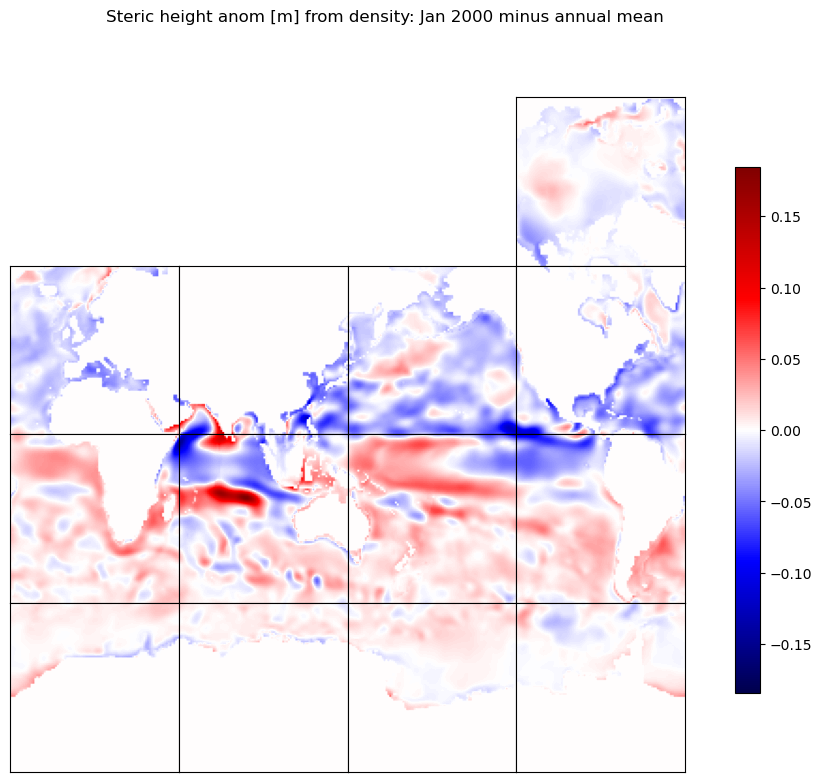

In [9]:
curr_obj = ecco.plot_tiles(steric_hgt_anom_dens.isel(time=0).squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
curr_fig.suptitle('Steric height anom [m] from density: Jan 2000 minus annual mean')

plt.show()

And from SSH - OBP:

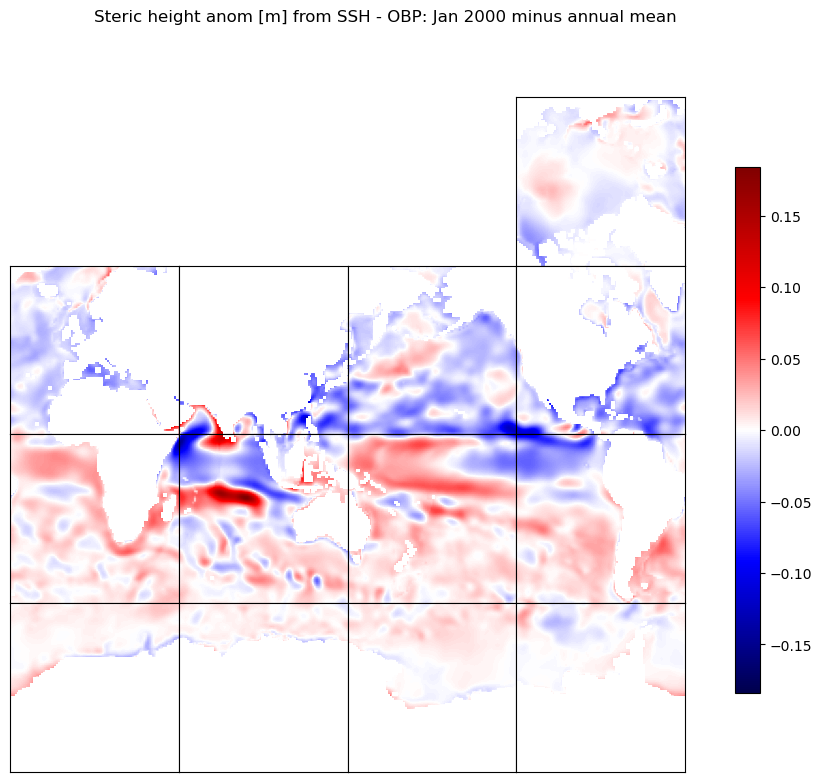

In [10]:
curr_obj = ecco.plot_tiles(steric_hgt_anom_SSH_OBP.isel(time=0).squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
curr_fig.suptitle('Steric height anom [m] from SSH - OBP: Jan 2000 minus annual mean')

plt.show()

I challenge you to identify (with just your eyes!) any differences between the two plots above. Though if we compute the difference between the two methods, some differences do emerge:

In [11]:
steric_diff = steric_hgt_anom_SSH_OBP - steric_hgt_anom_dens

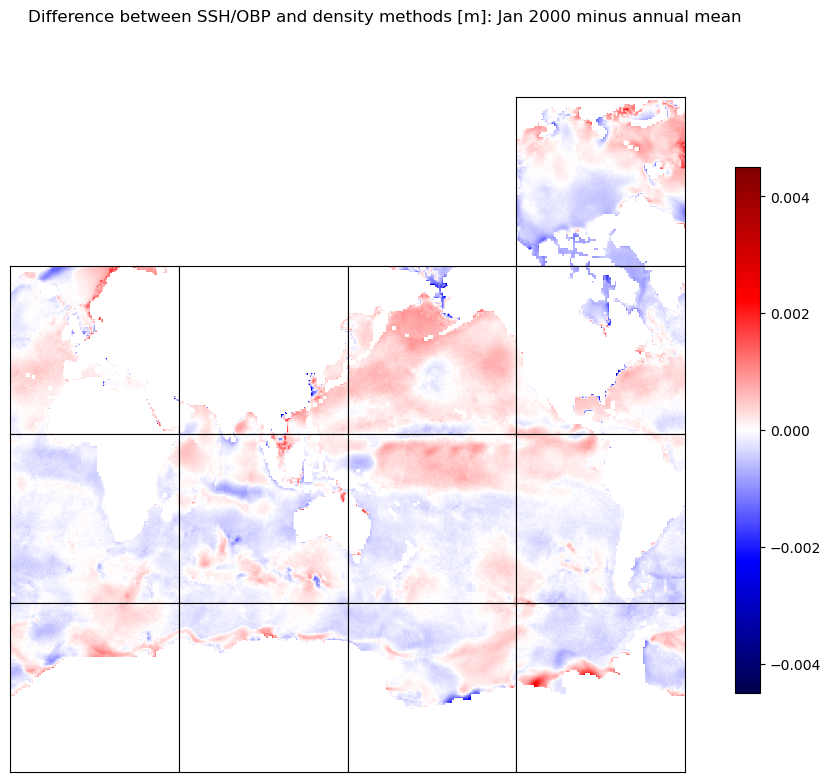

In [12]:
curr_obj = ecco.plot_tiles(steric_diff.isel(time=0).squeeze(),\
                            cmap='seismic',show_colorbar=True,fig_size=10,\
                            layout='latlon',rotate_to_latlon=True,\
                            show_tile_labels=False,\
                            Arctic_cap_tile_location=10)
curr_fig = curr_obj[0]
curr_fig.suptitle('Difference between SSH/OBP and density methods [m]: Jan 2000 minus annual mean')

plt.show()

Note the colorbar; most of the differences between the two methods are of order <1 mm. Very small compared to typical observational uncertainties, but not puny by ECCO standards.

We can also compare the global mean time series from the two methods:

In [13]:
# compute global ocean means

def global_ocean_mean_compute(field,ds_grid):
    spat_dims = ['tile','j','i']
    ocean_area = ds_grid.rA*ds_grid.hFacC.isel(k=0)
    global_mean = (ocean_area*field).sum(spat_dims)\
                        /(ocean_area.sum(spat_dims))

    return global_mean

steric_hgt_anom_dens_global = global_ocean_mean_compute(steric_hgt_anom_dens,ds_grid)
steric_hgt_anom_SSH_OBP_global = global_ocean_mean_compute(steric_hgt_anom_SSH_OBP,ds_grid)

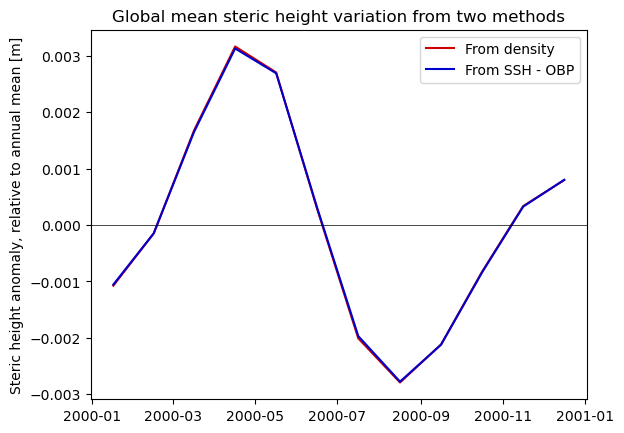

In [14]:
plt.plot(ds_dens.time.values,steric_hgt_anom_dens_global.values,\
            color=(.8,0,0),label='From density')
plt.plot(ds_SSH.time.values,steric_hgt_anom_SSH_OBP_global.values,\
            color=(0,0,.8),label='From SSH - OBP')
plt.axhline(y=0,color=(0,0,0),linewidth=0.5)
plt.ylabel('Steric height anomaly, relative to annual mean [m]')
plt.legend()
plt.title('Global mean steric height variation from two methods')
plt.show()

The two lines are virtually indistinguishable...though if you look closely you can see the red peeking out a bit. Now plot the difference:

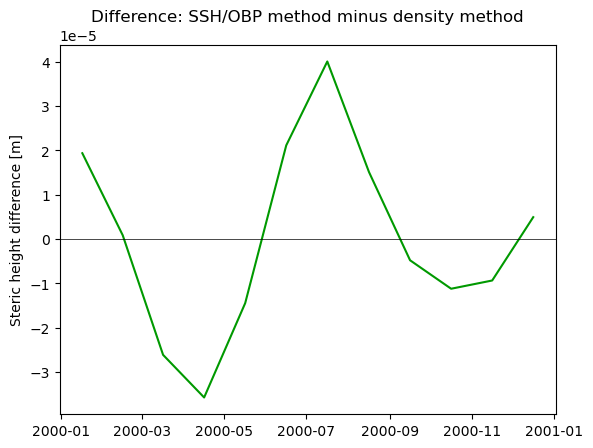

In [15]:
plt.plot(ds_SSH.time.values,(steric_hgt_anom_SSH_OBP_global - steric_hgt_anom_dens_global).values,\
            color=(0,.6,0))
plt.axhline(y=0,color=(0,0,0),linewidth=0.5)
plt.ylabel('Steric height difference [m]')
plt.title('Difference: SSH/OBP method minus density method')
plt.show()

The difference is about 2 orders of magnitude smaller than the "signal" of the steric height variation.

Fine enough for most geophysical investigations...yet why is there any difference? The patterns in the maps above suggest some actual physics rather than, say, numerical precision limitations. One possibility is that there are some high-frequency covariances in the quantities in our computation that we are unable to recover from the monthly means.

For example, the density method requires us to integrate a time-varying density field over a time-varying vertical integration range (because of the changing free surface, as indicated by `rstarfac`). When the water near the surface gets less dense, the free surface is likely to move up and `rstarfac` increases. These covariances may happen on diurnal or synoptic timescales, and we can not recover them from the monthly means.

## Global sea level closure and the volume budget

When considering the global sea level change and its mass (barystatic) and density (steric) components, it is worth remembering that the MITgcm (as a Boussinesq model) conserves volume and not mass. This distinction is not so important for local or regional gradients where density changes induce pressure gradients and a realistic dynamical response; however, global mean steric sea level changes do not induce pressure gradients. Rather, global steric expansion/contraction must be accounted for by computing the [Greatbatch correction](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/94JC00847) and applying it separately to the modeled sea level.

For more information on diagnosing the global sea level closure using ECCO, this [volume budget tutorial](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Volume_budget_closure.html) is a good place to start; note the [time series at the end](https://ecco-v4-python-tutorial.readthedocs.io/ECCO_v4_Volume_budget_closure.html#Remaining-components-of-sea-surface-height) that show the global mean steric sea level change along with the `ETAN` (liquid water mass) and sea ice loading components.